# Healthcare Risk Classification Using Logistic Regression and Naive Bayes

This notebook is a local healthcare data science project using the `insurance.csv` file in this repository.

I use the dataset to create a simple classification problem:

\[
\text{high\_cost} = 1 \quad \text{if charges are above the 75th percentile.}
\]

The aim is not to make a clinical tool. I am using the dataset to practise interpretable modelling, probability, coefficient interpretation, Bayes theorem, and model evaluation.

This project studies statistical relationships in the dataset and does not prove medical causation.

## 1. Introduction

I wanted this project to feel like something I could defend in an internship interview. The code is intentionally simple, but the explanations are careful.

The two models are:

- **Logistic Regression**, because it connects naturally to sigmoid functions, odds, log-odds, and coefficients.
- **Gaussian Naive Bayes**, because it connects directly to Bayes theorem and conditional probability.

The project is educational. The target is based on insurance charges, not a medical diagnosis, and the results should be interpreted as associations in this dataset rather than causal medical conclusions.

In [1]:
from pathlib import Path
import pickle
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", category=UserWarning)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "insurance.csv").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

DATA_PATH = PROJECT_ROOT / "insurance.csv"
OUTPUT_FIGURES = PROJECT_ROOT / "outputs" / "figures"
REPORT_FIGURES = PROJECT_ROOT / "report" / "figures"
OUTPUT_TABLES = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_MODELS = PROJECT_ROOT / "outputs" / "models"

for directory in [OUTPUT_FIGURES, REPORT_FIGURES, OUTPUT_TABLES, OUTPUT_MODELS]:
    directory.mkdir(parents=True, exist_ok=True)

# Remove old generated artifacts so reruns do not leave stale files.
for directory, patterns in [
    (OUTPUT_FIGURES, ["*.png"]),
    (REPORT_FIGURES, ["*.png"]),
    (OUTPUT_TABLES, ["*.csv"]),
    (OUTPUT_MODELS, ["*.pkl"]),
]:
    for pattern in patterns:
        for path in directory.glob(pattern):
            path.unlink()

FIGURE_DIRS = [OUTPUT_FIGURES, REPORT_FIGURES]

from preprocessing import (
    MODEL_FEATURES,
    add_healthcare_features,
    get_feature_target,
    load_insurance_data,
    make_train_test_split,
)
from models import (
    build_logistic_regression,
    build_naive_bayes,
    logistic_coefficient_table,
)
from evaluation import comparison_table, evaluate_classifier, model_confusion_matrix
from visualization import (
    plot_charges_distribution,
    plot_charges_scatter,
    plot_class_balance,
    plot_confusion_matrix_figure,
    plot_correlation_matrix,
    plot_log_charges_distribution,
    plot_rate_by_group,
)

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")

Project root: /Users/namem/Documents/Codex
Data path: /Users/namem/Documents/Codex/insurance.csv


## 2. Dataset Overview

The dataset contains medical insurance cost records. Before modelling, I inspect the basic structure: shape, first rows, data types, missing values, and descriptive statistics.

Variables:

- `age`: age of the insurance beneficiary.
- `sex`: recorded sex category.
- `bmi`: body mass index.
- `children`: number of covered children.
- `smoker`: whether the person is recorded as a smoker.
- `region`: residential region.
- `charges`: individual medical insurance charges.

In [2]:
raw_df = load_insurance_data(DATA_PATH)
print("Dataset shape:", raw_df.shape)
display(raw_df.head())

Dataset shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
column_overview = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing_values": raw_df.isna().sum(),
    "missing_rate": raw_df.isna().mean().round(3),
})
display(column_overview)

,dtype,missing_values,missing_rate
age,int64,0,0.0
sex,str,0,0.0
bmi,float64,0,0.0
children,int64,0,0.0
smoker,str,0,0.0
region,str,0,0.0
charges,float64,0,0.0


In [4]:
display(raw_df.describe(include="all").transpose())

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1338.0,NaN,NaN,NaN,39.207025,14.04996,18.0,27.0,39.0,51.0,64.0
sex,1338,2,male,676,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,1338.0,NaN,NaN,NaN,30.663397,6.098187,15.96,26.29625,30.4,34.69375,53.13
children,1338.0,NaN,NaN,NaN,1.094918,1.205493,0.0,0.0,1.0,2.0,5.0
smoker,1338,2,no,1064,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,1338,4,southeast,364,NaN,NaN,NaN,NaN,NaN,NaN,NaN
charges,1338.0,NaN,NaN,NaN,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


There are no missing values in this file. The numerical variables are `age`, `bmi`, `children`, and `charges`. The categorical variables are `sex`, `smoker`, and `region`.

## 3. Feature Engineering

I create three new columns:

- `high_cost`: the target variable.
- `bmi_category`: a simple grouping of BMI into normal, overweight, and obese.
- `age_group`: a simple grouping of age into young, middle, and older.

The 75th percentile threshold is useful because it defines a clear high-cost group. It is still arbitrary and educational, not a clinical threshold.

In [5]:
df, high_cost_threshold = add_healthcare_features(raw_df)

print(f"75th percentile charge threshold: ${high_cost_threshold:,.2f}")
display(df[["age", "bmi", "charges", "high_cost", "bmi_category", "age_group"]].head())

75th percentile charge threshold: $16,639.91


,age,bmi,charges,high_cost,bmi_category,age_group
0,19,27.900,16884.92400,1,overweight,young
1,18,33.770,1725.55230,0,obese,young
2,28,33.000,4449.46200,0,obese,young
3,33,22.705,21984.47061,1,normal,middle
4,32,28.880,3866.85520,0,overweight,middle


In [6]:
class_summary = pd.DataFrame({
    "count": df["high_cost"].value_counts().sort_index(),
    "rate": df["high_cost"].value_counts(normalize=True).sort_index().round(3),
})
class_summary.index = ["not_high_cost", "high_cost"]
display(class_summary)

,count,rate
not_high_cost,1003,0.75
high_cost,335,0.25


The positive class is smaller because only records above the 75th percentile are labelled as high cost. This means accuracy should not be the only metric I look at.

## 4. Exploratory Data Analysis

The figures in this section are saved to:

- `outputs/figures/`
- `report/figures/`

I save a second copy for the report so the LaTeX file can compile without manual moving of images.

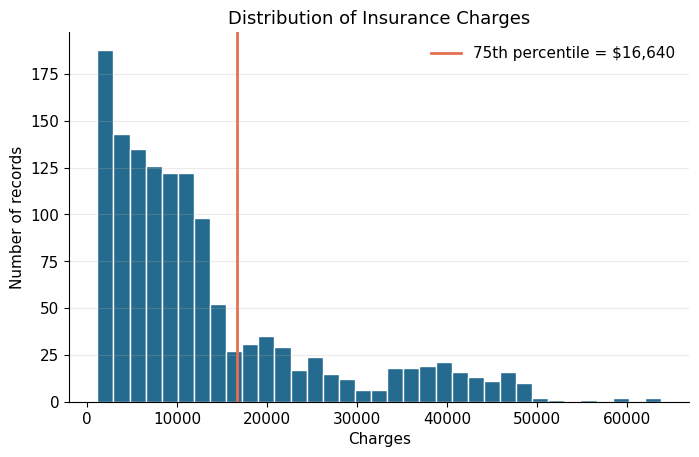

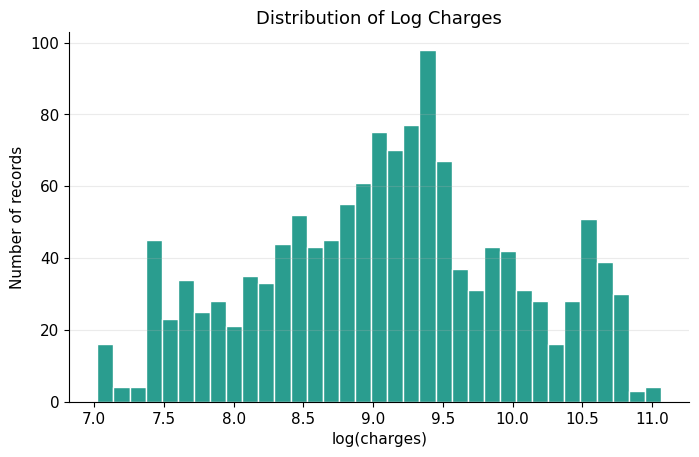

In [7]:
fig, _ = plot_charges_distribution(df, high_cost_threshold, FIGURE_DIRS)
plt.show()
plt.close(fig)

fig, _ = plot_log_charges_distribution(df, FIGURE_DIRS)
plt.show()
plt.close(fig)

The charges distribution is strongly right-skewed. Taking `log(charges)` makes the shape easier to inspect, although I do not use charges or log charges as features because they define the target.

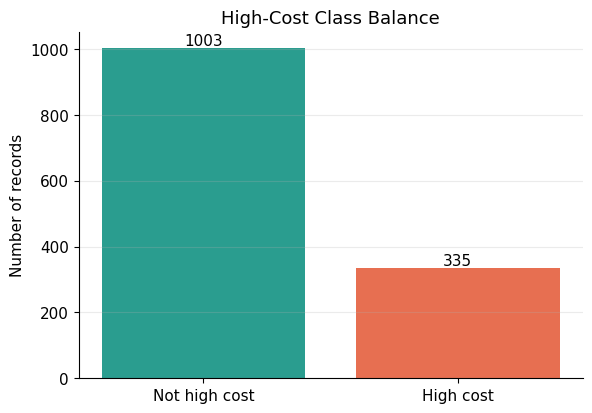

In [8]:
fig, _ = plot_class_balance(df, FIGURE_DIRS)
plt.show()
plt.close(fig)

The class balance confirms the target construction: most records are not high cost, and roughly one quarter are high cost.

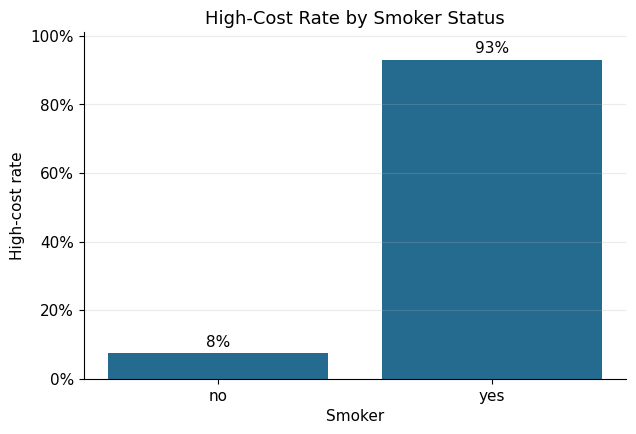

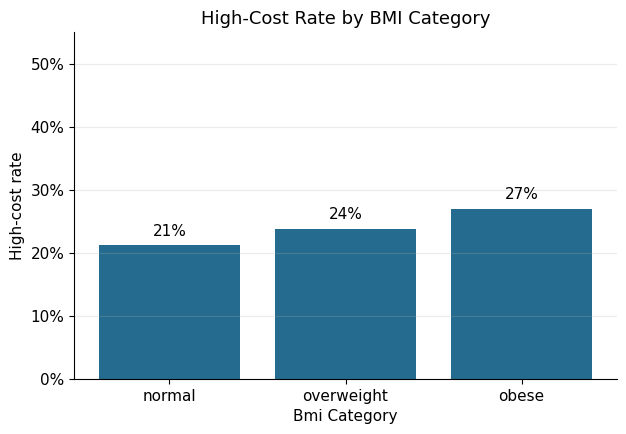

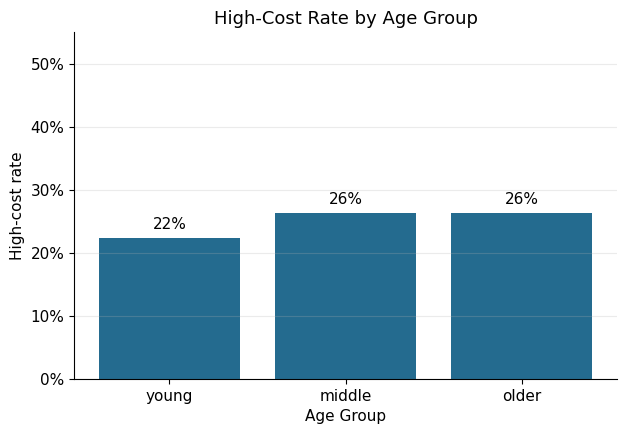

In [9]:
fig, _ = plot_rate_by_group(
    df,
    group_column="smoker",
    title="High-Cost Rate by Smoker Status",
    filename="high_cost_rate_by_smoker.png",
    output_dirs=FIGURE_DIRS,
    order=["no", "yes"],
)
plt.show()
plt.close(fig)

fig, _ = plot_rate_by_group(
    df,
    group_column="bmi_category",
    title="High-Cost Rate by BMI Category",
    filename="high_cost_rate_by_bmi_category.png",
    output_dirs=FIGURE_DIRS,
    order=["normal", "overweight", "obese"],
)
plt.show()
plt.close(fig)

fig, _ = plot_rate_by_group(
    df,
    group_column="age_group",
    title="High-Cost Rate by Age Group",
    filename="high_cost_rate_by_age_group.png",
    output_dirs=FIGURE_DIRS,
    order=["young", "middle", "older"],
)
plt.show()
plt.close(fig)

One interesting observation is that smoking status separates the high-cost group quite strongly. BMI category and age group also show patterns, but I need to be careful: these are statistical associations, not proof that a variable causes high insurance charges.

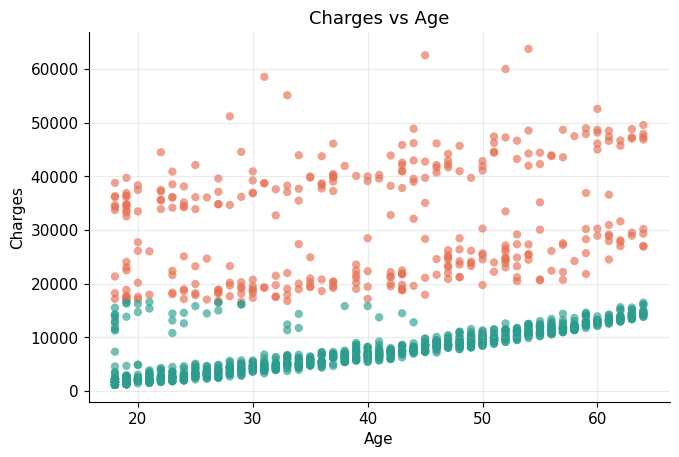

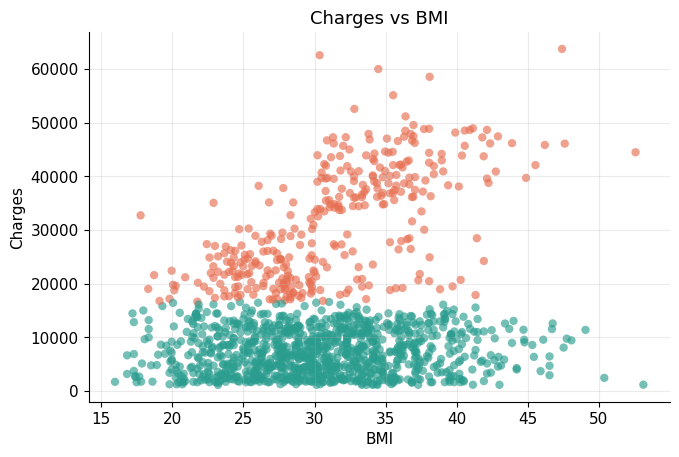

In [10]:
fig, _ = plot_charges_scatter(
    df,
    x_column="age",
    title="Charges vs Age",
    filename="charges_vs_age.png",
    output_dirs=FIGURE_DIRS,
)
plt.show()
plt.close(fig)

fig, _ = plot_charges_scatter(
    df,
    x_column="bmi",
    title="Charges vs BMI",
    filename="charges_vs_bmi.png",
    output_dirs=FIGURE_DIRS,
)
plt.show()
plt.close(fig)

The scatter plots show that high charges are not explained by one variable alone. There are visible patterns with age and BMI, but the points also show a lot of variation.

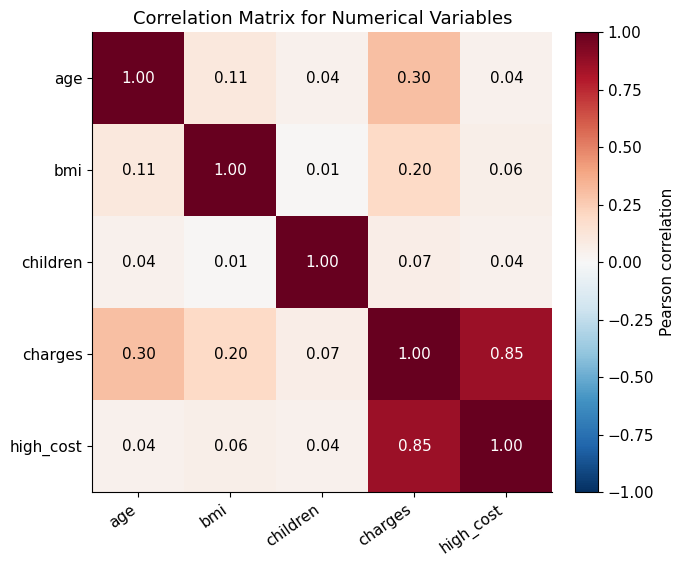

,age,bmi,children,charges,high_cost
age,1.000,0.109,0.042,0.299,0.040
bmi,0.109,1.000,0.013,0.198,0.061
children,0.042,0.013,1.000,0.068,0.040
charges,0.299,0.198,0.068,1.000,0.852
high_cost,0.040,0.061,0.040,0.852,1.000


In [11]:
numerical_columns = ["age", "bmi", "children", "charges", "high_cost"]
fig, _, corr = plot_correlation_matrix(df, numerical_columns, FIGURE_DIRS)
plt.show()
plt.close(fig)

corr.round(3).to_csv(OUTPUT_TABLES / "numerical_correlation_matrix.csv")
display(corr.round(3))

The correlation matrix is useful for checking linear relationships between numerical variables. Correlation is still not causation, especially in an observational dataset like this one.

In [12]:
eda_rates = pd.DataFrame({
    "group": [
        "smoker=no", "smoker=yes",
        "bmi=normal", "bmi=overweight", "bmi=obese",
        "age=young", "age=middle", "age=older",
    ],
    "high_cost_rate": [
        df.loc[df["smoker"] == "no", "high_cost"].mean(),
        df.loc[df["smoker"] == "yes", "high_cost"].mean(),
        df.loc[df["bmi_category"] == "normal", "high_cost"].mean(),
        df.loc[df["bmi_category"] == "overweight", "high_cost"].mean(),
        df.loc[df["bmi_category"] == "obese", "high_cost"].mean(),
        df.loc[df["age_group"] == "young", "high_cost"].mean(),
        df.loc[df["age_group"] == "middle", "high_cost"].mean(),
        df.loc[df["age_group"] == "older", "high_cost"].mean(),
    ],
})
eda_rates["high_cost_rate"] = eda_rates["high_cost_rate"].round(3)
eda_rates.to_csv(OUTPUT_TABLES / "eda_high_cost_rates.csv", index=False)
display(eda_rates)

,group,high_cost_rate
0,smoker=no,0.075
1,smoker=yes,0.931
2,bmi=normal,0.212
3,bmi=overweight,0.238
4,bmi=obese,0.270
5,age=young,0.223
6,age=middle,0.263
7,age=older,0.262


## Train/Test Split

I now prepare the model features and target. The features are `age`, `bmi`, `children`, `sex`, `smoker`, and `region`. I do not include `charges` because it was used to create the target.

I use a stratified 80/20 train/test split so that both sets have a similar high-cost class proportion.

In [13]:
X, y = get_feature_target(df)
X_train, X_test, y_train, y_test = make_train_test_split(X, y, test_size=0.20, random_state=42)

print("Model features:", MODEL_FEATURES)
print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training high-cost rate:", round(y_train.mean(), 3))
print("Test high-cost rate:", round(y_test.mean(), 3))

Model features: ['age', 'bmi', 'children', 'sex', 'smoker', 'region']
Training shape: (1070, 6)
Test shape: (268, 6)
Training high-cost rate: 0.25
Test high-cost rate: 0.25


## 5. Logistic Regression

Logistic regression models the probability that `high_cost = 1`.

It starts with a linear score:

\[
z = \beta_0 + \beta_1x_1 + \cdots + \beta_dx_d
\]

Then it applies the sigmoid function:

\[
p = \frac{1}{1 + \exp(-z)}
\]

The logit form is:

\[
\log\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1x_1 + \cdots + \beta_dx_d
\]

The quantity \(p/(1-p)\) is the odds. A coefficient changes the log-odds, and \(\exp(\beta_j)\) is the odds multiplier for a one-unit increase in feature \(x_j\), holding other features fixed.

This is an interpretation of association inside the fitted model. It does not prove causality.

In [14]:
logistic_model = build_logistic_regression()
logistic_model.fit(X_train, y_train)

logistic_metrics = evaluate_classifier("Logistic Regression", logistic_model, X_test, y_test)
display(pd.DataFrame([logistic_metrics]).round(3))

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.914,0.94,0.701,0.803


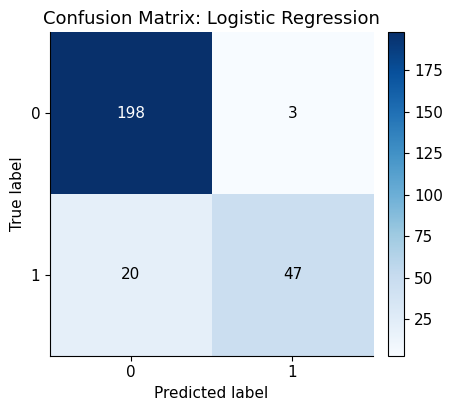

In [15]:
logistic_cm = model_confusion_matrix(logistic_model, X_test, y_test)
fig, _ = plot_confusion_matrix_figure(
    logistic_cm,
    title="Confusion Matrix: Logistic Regression",
    filename="confusion_matrix_logistic_regression.png",
    output_dirs=FIGURE_DIRS,
)
plt.show()
plt.close(fig)

In [16]:
coef_df = pd.DataFrame(logistic_coefficient_table(logistic_model))
coef_df.to_csv(OUTPUT_TABLES / "logistic_coefficients.csv", index=False)
display(coef_df.round(3))

,feature,coefficient_log_odds,odds_multiplier
0,smoker_yes,4.985,146.163
1,region_southwest,-0.333,0.717
2,children,0.164,1.178
3,region_southeast,0.151,1.163
4,sex_male,0.128,1.136
5,region_northwest,0.090,1.094
6,bmi,0.036,1.036
7,age,0.027,1.028


The largest coefficient is for `smoker_yes`, which matches the exploratory plots. I would describe this as a strong association in the dataset, not as proof that the model has discovered a medical cause.

## 6. Naive Bayes

Naive Bayes is based on Bayes theorem:

\[
P(Y \mid X) = \frac{P(X \mid Y)P(Y)}{P(X)}
\]

Here:

- \(P(Y)\) is the prior class probability.
- \(P(X)\) is the evidence.
- \(P(Y \mid X)\) is the posterior probability after observing the features.

The Naive Bayes assumption is:

\[
P(x_1, \ldots, x_d \mid Y) = \prod_j P(x_j \mid Y)
\]

This means the features are treated as conditionally independent given the class. That assumption is simple and useful for learning, but probably unrealistic for real healthcare data.

In [17]:
naive_bayes_model = build_naive_bayes()
naive_bayes_model.fit(X_train, y_train)

naive_bayes_metrics = evaluate_classifier("Naive Bayes", naive_bayes_model, X_test, y_test)
display(pd.DataFrame([naive_bayes_metrics]).round(3))

,model,accuracy,precision,recall,f1_score
0,Naive Bayes,0.914,0.94,0.701,0.803


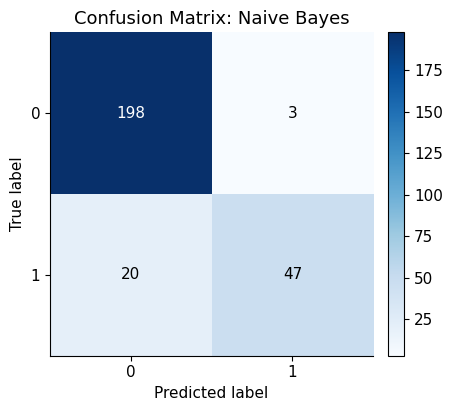

In [18]:
naive_bayes_cm = model_confusion_matrix(naive_bayes_model, X_test, y_test)
fig, _ = plot_confusion_matrix_figure(
    naive_bayes_cm,
    title="Confusion Matrix: Naive Bayes",
    filename="confusion_matrix_naive_bayes.png",
    output_dirs=FIGURE_DIRS,
)
plt.show()
plt.close(fig)

Naive Bayes is easy to explain mathematically, but its independence assumption is a real limitation. I see it as a useful baseline rather than a final healthcare model.

## 7. Model Comparison

I compare only Logistic Regression and Naive Bayes.

Metrics:

- **Accuracy**: overall proportion of correct predictions.
- **Precision**: among predicted high-cost records, how many were truly high cost.
- **Recall**: among truly high-cost records, how many the model found.
- **F1-score**: a balance between precision and recall.

I keep the evaluation focused on the basic metrics I can explain confidently.

In [19]:
comparison = comparison_table([logistic_metrics, naive_bayes_metrics])
comparison.to_csv(OUTPUT_TABLES / "model_comparison.csv", index=False)
display(comparison)

,model,accuracy,precision,recall,f1_score
0,Logistic Regression,0.914,0.94,0.701,0.803
1,Naive Bayes,0.914,0.94,0.701,0.803


In [20]:
fitted_models = {
    "logistic_regression": logistic_model,
    "naive_bayes": naive_bayes_model,
}

for model_name, model in fitted_models.items():
    with open(OUTPUT_MODELS / f"{model_name}.pkl", "wb") as file:
        pickle.dump(model, file)

print("Saved model files:")
for path in sorted(OUTPUT_MODELS.glob("*.pkl")):
    print("-", path.relative_to(PROJECT_ROOT))

Saved model files:
- outputs/models/logistic_regression.pkl
- outputs/models/naive_bayes.pkl


The two models perform similarly on this split. Logistic regression is easier for me to interpret through coefficients and odds, while Naive Bayes is useful for explaining Bayes theorem and the independence assumption.

I would avoid saying either model is generally better based on this single test split.

## 8. Final Observations

### Main Observations

One interesting observation was that smoking status separated the classes quite strongly. I also noticed visible patterns with age and BMI, but these are associations in the dataset rather than medical conclusions.

### What I Learned

I learned that simple models still require careful explanation. Logistic regression is not just a classifier; it has a clear mathematical interpretation through odds and log-odds. Naive Bayes is simple to code, but the independence assumption matters.

### Simple Limitations

The target threshold is arbitrary and educational. The dataset is small and simplified. The models are trained on one train/test split. The analysis does not prove causality.

### Future Improvements

A natural next step would be cross-validation, probability calibration, and trying different high-cost thresholds. I would also add a short fairness discussion before using variables such as sex or region in any serious setting.

This project studies statistical relationships in the dataset and does not prove medical causation.

In [21]:
expected_files = [
    "outputs/figures/charges_distribution.png",
    "outputs/figures/log_charges_distribution.png",
    "outputs/figures/high_cost_class_balance.png",
    "outputs/figures/high_cost_rate_by_smoker.png",
    "outputs/figures/high_cost_rate_by_bmi_category.png",
    "outputs/figures/high_cost_rate_by_age_group.png",
    "outputs/figures/charges_vs_age.png",
    "outputs/figures/charges_vs_bmi.png",
    "outputs/figures/correlation_matrix.png",
    "outputs/figures/confusion_matrix_logistic_regression.png",
    "outputs/figures/confusion_matrix_naive_bayes.png",
    "outputs/tables/model_comparison.csv",
    "outputs/tables/logistic_coefficients.csv",
    "outputs/tables/numerical_correlation_matrix.csv",
    "outputs/models/logistic_regression.pkl",
    "outputs/models/naive_bayes.pkl",
]

print("Generated file check:")
for relative_path in expected_files:
    path = PROJECT_ROOT / relative_path
    print(f"- {relative_path}: {'OK' if path.exists() else 'MISSING'}")

Generated file check:
- outputs/figures/charges_distribution.png: OK
- outputs/figures/log_charges_distribution.png: OK
- outputs/figures/high_cost_class_balance.png: OK
- outputs/figures/high_cost_rate_by_smoker.png: OK
- outputs/figures/high_cost_rate_by_bmi_category.png: OK
- outputs/figures/high_cost_rate_by_age_group.png: OK
- outputs/figures/charges_vs_age.png: OK
- outputs/figures/charges_vs_bmi.png: OK
- outputs/figures/correlation_matrix.png: OK
- outputs/figures/confusion_matrix_logistic_regression.png: OK
- outputs/figures/confusion_matrix_naive_bayes.png: OK
- outputs/tables/model_comparison.csv: OK
- outputs/tables/logistic_coefficients.csv: OK
- outputs/tables/numerical_correlation_matrix.csv: OK
- outputs/models/logistic_regression.pkl: OK
- outputs/models/naive_bayes.pkl: OK
